In [ ]:
from plotnine import *
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from scipy.stats import ks_2samp

In [35]:
models = ["nlmixr2", "Jinkō"]


run_id = "20260923_1349"


def data_path(model, kind):
    if model == "nlmixr2" and kind == "map":
        return f"./nlmixr2/nlmixr2_map_{run_id}.csv"
    if model == "nlmixr2" and kind == "VPC":
        return f"./nlmixr2/nlmixr2_vpc_{run_id}.csv"
    if model == "Jinkō" and kind == "map":
        return f"./jinko/jinko_map_{run_id}.csv"
    if model == "Jinkō" and kind == "VPC":
        return f"./jinko/jinko_vpc_{run_id}.csv"
    else:
        return Exception(f"Unknown model={model}, kind={kind} in data_path()")


Order = ["nlmixr2 (R)", "Jinkō"]

source_names = dict(zip(["nlmixr2", "Jinkō"], Order))

Colors = dict(zip(Order, ["#0072B2", "#D55E00"]))  # , "#E69F00", "#009E73"]))


def canon_source(s):
    return pd.Categorical(
        pd.Series(s).map(lambda x: source_names.get(x, x)),
        categories=Order,
        ordered=True,
    )


figsize = (12, 12)

poster_theme = theme_bw(base_size=18) + theme(
    figure_size=figsize,
    plot_title=element_text(size=20, weight="bold", margin={"b": 10, "unit": "pt"}),
    legend_title=element_text(weight="bold"),
    panel_grid_minor=element_blank(),
    strip_background=element_rect(fill="#EDEDED", color="none"),
    strip_text=element_text(weight="bold"),
    legend_box_spacing=0,  # legend → plot-panel gap, in points
    legend_margin=0,  # padding inside the legend box
)

source_fill = scale_fill_manual(values=Colors, name="Source", limits=Order)
source_color = scale_color_manual(values=Colors, name="Source", limits=Order)

## Convergence benchmark data

In [36]:
params = ["CLint", "KbBR", "KbMU", "KbBO", "KbAD", "KbRB"]


def load_map(model):
    df = pd.read_csv(data_path(model, "map"))
    if "id_ref" in df.columns:
        df = df.rename(columns={"id_ref": "ID"})
    out = df[["ID"] + params].copy()
    out["algo"] = model
    return out


def process_map_data(models=models):
    map_df = pd.concat([load_map(m) for m in models], ignore_index=True)
    return map_df.melt(
        id_vars=["ID", "algo"], value_vars=params, var_name="descriptor"
    ).reset_index(drop=True)

In [37]:
map_obs = process_map_data()
display(map_obs.head())

,ID,algo,descriptor,value
0,793,nlmixr2,CLint,865.788446
1,794,nlmixr2,CLint,1131.503865
2,795,nlmixr2,CLint,1332.198169
3,796,nlmixr2,CLint,1473.874011
4,797,nlmixr2,CLint,745.408217


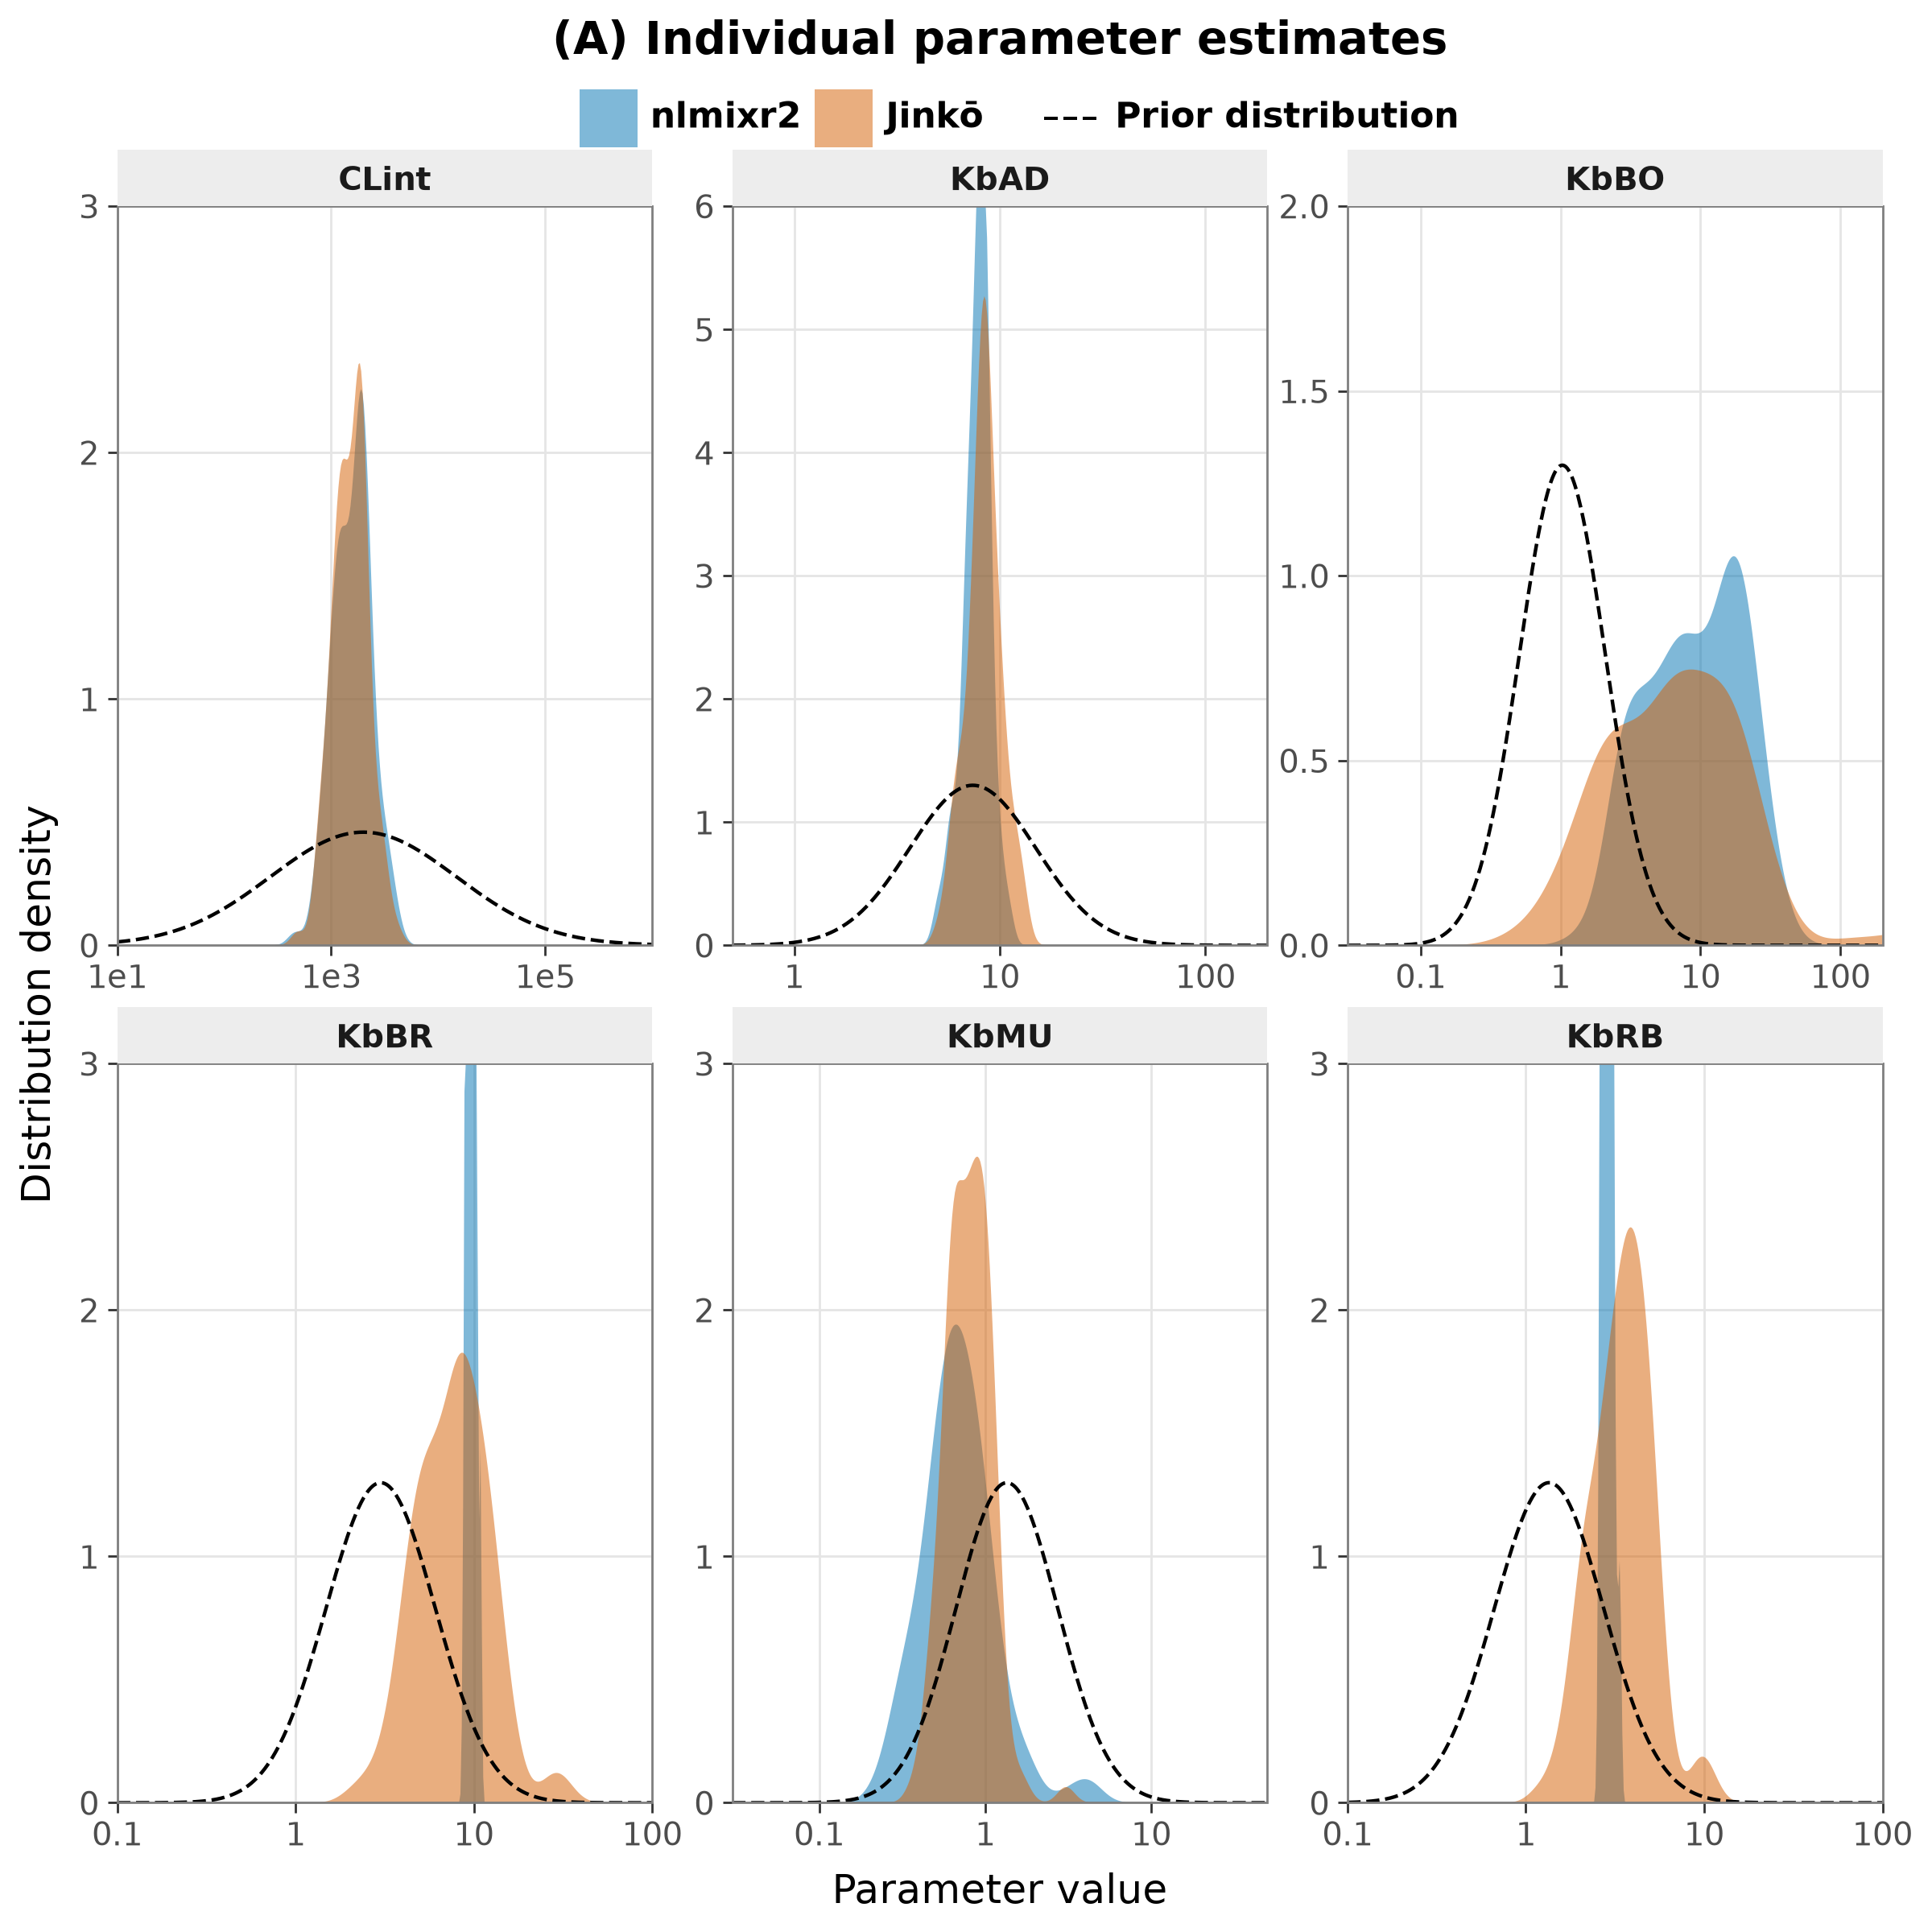

In [38]:
map_obs = map_obs.copy()
map_source_labels = {"nlmixr2": "nlmixr2", "Jinkō": "Jinkō"}
map_sources = list(map_source_labels.values())
map_colors = {"nlmixr2": "#0072B2", "Jinkō": "#D55E00"}
map_obs["Source"] = pd.Categorical(
    map_obs["algo"].map(map_source_labels),
    categories=map_sources,
    ordered=True,
)
map_obs["descriptor"] = pd.Categorical(
    map_obs["descriptor"],
    categories=["CLint", "KbAD", "KbBO", "KbBR", "KbMU", "KbRB"],
    ordered=True,
)

# Edit these six entries to set each facet's displayed x- and y-axis ranges.
panel_ranges = {
    "CLint": {"x": (10, 1e6), "y": (0, 3)},
    "KbAD": {"x": (0.5, 200), "y": (0, 6)},
    "KbBO": {"x": (0.03, 200), "y": (0, 2)},
    "KbBR": {"x": (0.1, 100), "y": (0, 3)},
    "KbMU": {"x": (0.03, 50), "y": (0, 3)},
    "KbRB": {"x": (0.1, 100), "y": (0, 3)},
}

# PDU priors: log(value) ~ Normal(log(prior), prior_omega).
# geom_density runs after the log10 x-scale transform, so calculate densities on that scale.
prior_specs = {
    "KbBR": {"prior": np.exp(1.1), "prior_omega": 0.5},
    "KbMU": {"prior": np.exp(0.3), "prior_omega": 0.5},
    "KbAD": {"prior": np.exp(2), "prior_omega": 0.5},
    "CLint": {"prior": np.exp(7.6), "prior_omega": 4},
    "KbBO": {"prior": np.exp(0.03), "prior_omega": 0.5},
    "KbRB": {"prior": np.exp(0.3), "prior_omega": 0.5},
}

prior_curves = []
for descriptor, spec in prior_specs.items():
    meanlog = np.log(spec["prior"])
    sdlog = np.sqrt(spec["prior_omega"])
    x_min, x_max = panel_ranges[descriptor]["x"]
    y_min, y_max = panel_ranges[descriptor]["y"]
    log10_mean = meanlog / np.log(10)
    log10_sd = sdlog / np.log(10)
    log10_values = np.linspace(np.log10(x_min), np.log10(x_max), 400)
    values = 10**log10_values
    density = np.exp(-0.5 * ((log10_values - log10_mean) / log10_sd) ** 2) / (
        log10_sd * np.sqrt(2 * np.pi)
    )
    density = np.clip(density, y_min, y_max)
    prior_curves.append(
        pd.DataFrame({"descriptor": descriptor, "value": values, "density": density})
    )

prior_curves = pd.concat(prior_curves, ignore_index=True)
prior_curves["descriptor"] = pd.Categorical(
    prior_curves["descriptor"],
    categories=map_obs["descriptor"].cat.categories,
    ordered=True,
)
prior_curves["Distribution"] = "Prior distribution"

# Estimate the fitted distributions on each facet's manually specified log10 x-grid.
estimate_curves = []
for (descriptor, source), group in map_obs.groupby(
    ["descriptor", "Source"], observed=True
):
    x_min, x_max = panel_ranges[descriptor]["x"]
    y_min, y_max = panel_ranges[descriptor]["y"]
    log10_values = np.linspace(np.log10(x_min), np.log10(x_max), 400)
    density = gaussian_kde(np.log10(group["value"].to_numpy()))(log10_values)
    estimate_curves.append(
        pd.DataFrame(
            {
                "descriptor": descriptor,
                "Source": source,
                "value": 10**log10_values,
                "density": np.clip(density, y_min, y_max),
            }
        )
    )

estimate_curves = pd.concat(estimate_curves, ignore_index=True)
estimate_curves["descriptor"] = pd.Categorical(
    estimate_curves["descriptor"],
    categories=map_obs["descriptor"].cat.categories,
    ordered=True,
)
estimate_curves["Source"] = pd.Categorical(
    estimate_curves["Source"], categories=map_sources, ordered=True
)

# Invisible corners force the exact range for each free-scale facet.
axis_limits = pd.DataFrame(
    [
        {"descriptor": descriptor, "value": x, "density": y}
        for descriptor, limits in panel_ranges.items()
        for x, y in (
            (limits["x"][0], limits["y"][0]),
            (limits["x"][1], limits["y"][1]),
        )
    ]
)
axis_limits["descriptor"] = pd.Categorical(
    axis_limits["descriptor"],
    categories=map_obs["descriptor"].cat.categories,
    ordered=True,
)

(
    ggplot()
    + geom_blank(axis_limits, aes(x="value", y="density"), inherit_aes=False)
    + geom_area(
        estimate_curves,
        aes(x="value", y="density", fill="Source", group="Source"),
        alpha=0.5,
        color=None,
        position="identity",
    )
    + geom_line(
        prior_curves,
        aes(
            x="value",
            y="density",
            linetype="Distribution",
            group="descriptor",
        ),
        inherit_aes=False,
        color="black",
        size=0.9,
    )
    + facet_wrap("~descriptor", ncol=3, scales="free")
    + scale_x_continuous(trans="log10", expand=(0, 0))
    + scale_y_continuous(expand=(0, 0))
    + scale_fill_manual(values=map_colors, name=None, limits=map_sources)
    + scale_linetype_manual(values={"Prior distribution": "dashed"}, name=None)
    + guides(
        fill=guide_legend(title="", order=1),
        linetype=guide_legend(title="", order=2),
    )
    + labs(
        x="Parameter value",
        y="Distribution density",
        title="(A) Individual parameter estimates",
    )
    + poster_theme
    + theme(
        legend_position="top",
        legend_box="horizontal",
        legend_direction="horizontal",
        legend_text=element_text(size=16, weight="bold"),
    )
)

In [39]:
# Summarize natural logs of the individual estimates, independent of plot ranges.
# SD is the sample standard deviation (ddof=1); KS is the two-sided statistic.
summary_rows = []
for parameter in params:
    log_samples = {}
    for model in ("nlmixr2", "Jinkō"):
        values = map_obs.loc[
            (map_obs["descriptor"] == parameter) & (map_obs["algo"] == model),
            "value",
        ].to_numpy(dtype=float)
        if len(values) < 2 or not np.isfinite(values).all() or (values <= 0).any():
            raise ValueError(
                f"{model}: {parameter} requires at least two finite, positive estimates."
            )
        log_samples[model] = np.log(values)

    log_nlmixr2 = log_samples["nlmixr2"]
    log_jinko = log_samples["Jinkō"]
    summary_rows.append(
        {
            "Parameter": f"log({parameter})",
            "mean (nlmixr2)": log_nlmixr2.mean(),
            "mean (Jinkō)": log_jinko.mean(),
            "SD (nlmixr2)": log_nlmixr2.std(ddof=1),
            "SD (Jinkō)": log_jinko.std(ddof=1),
            "KS statistic": ks_2samp(
                log_nlmixr2, log_jinko, alternative="two-sided"
            ).statistic,
        }
    )

log_parameter_summary = pd.DataFrame(summary_rows).set_index("Parameter")
display(log_parameter_summary.style.format("{:.2f}"))

,mean (nlmixr2),mean (Jinkō),SD (nlmixr2),SD (Jinkō),KS statistic
Parameter,,,,,
log(CLint),7.37,7.33,0.40,0.38,0.10
log(KbBR),2.28,2.03,0.04,0.48,0.64
log(KbMU),-0.37,-0.23,0.51,0.31,0.24
log(KbBO),2.20,1.88,0.78,1.13,0.21
log(KbAD),2.05,2.13,0.15,0.19,0.26
log(KbRB),1.06,1.24,0.05,0.39,0.59


## VPC Benchmark Data

In [40]:
VPC_nlmixr2 = pd.read_csv(data_path("nlmixr2", "VPC"))
VPC_Simwork = pd.read_csv(data_path("Jinkō", "VPC"))
# VPC_Sbml = pd.read_csv(data_path("Sbml", "VPC"))
# VPC_Surrogate = pd.read_csv(data_path("Simwork_surrogate", "VPC"))

VPC_Simwork["bin_center"] = VPC_Simwork["bin_center"] / 3600.0

VPC_nlmixr2["model"] = "nlmixr2"
VPC_Simwork["model"] = "Jinkō"
# VPC_Surrogate["model"] = "Simwork_surrogate"

vpc_data = pd.concat([VPC_nlmixr2, VPC_Simwork], ignore_index=True)

for c in ["q_obs", "pred_median", "pred_lower", "pred_upper"]:
    vpc_data[c] = np.exp(vpc_data[c])

vpc_data["model"] = pd.Categorical(vpc_data["model"], categories=models, ordered=True)

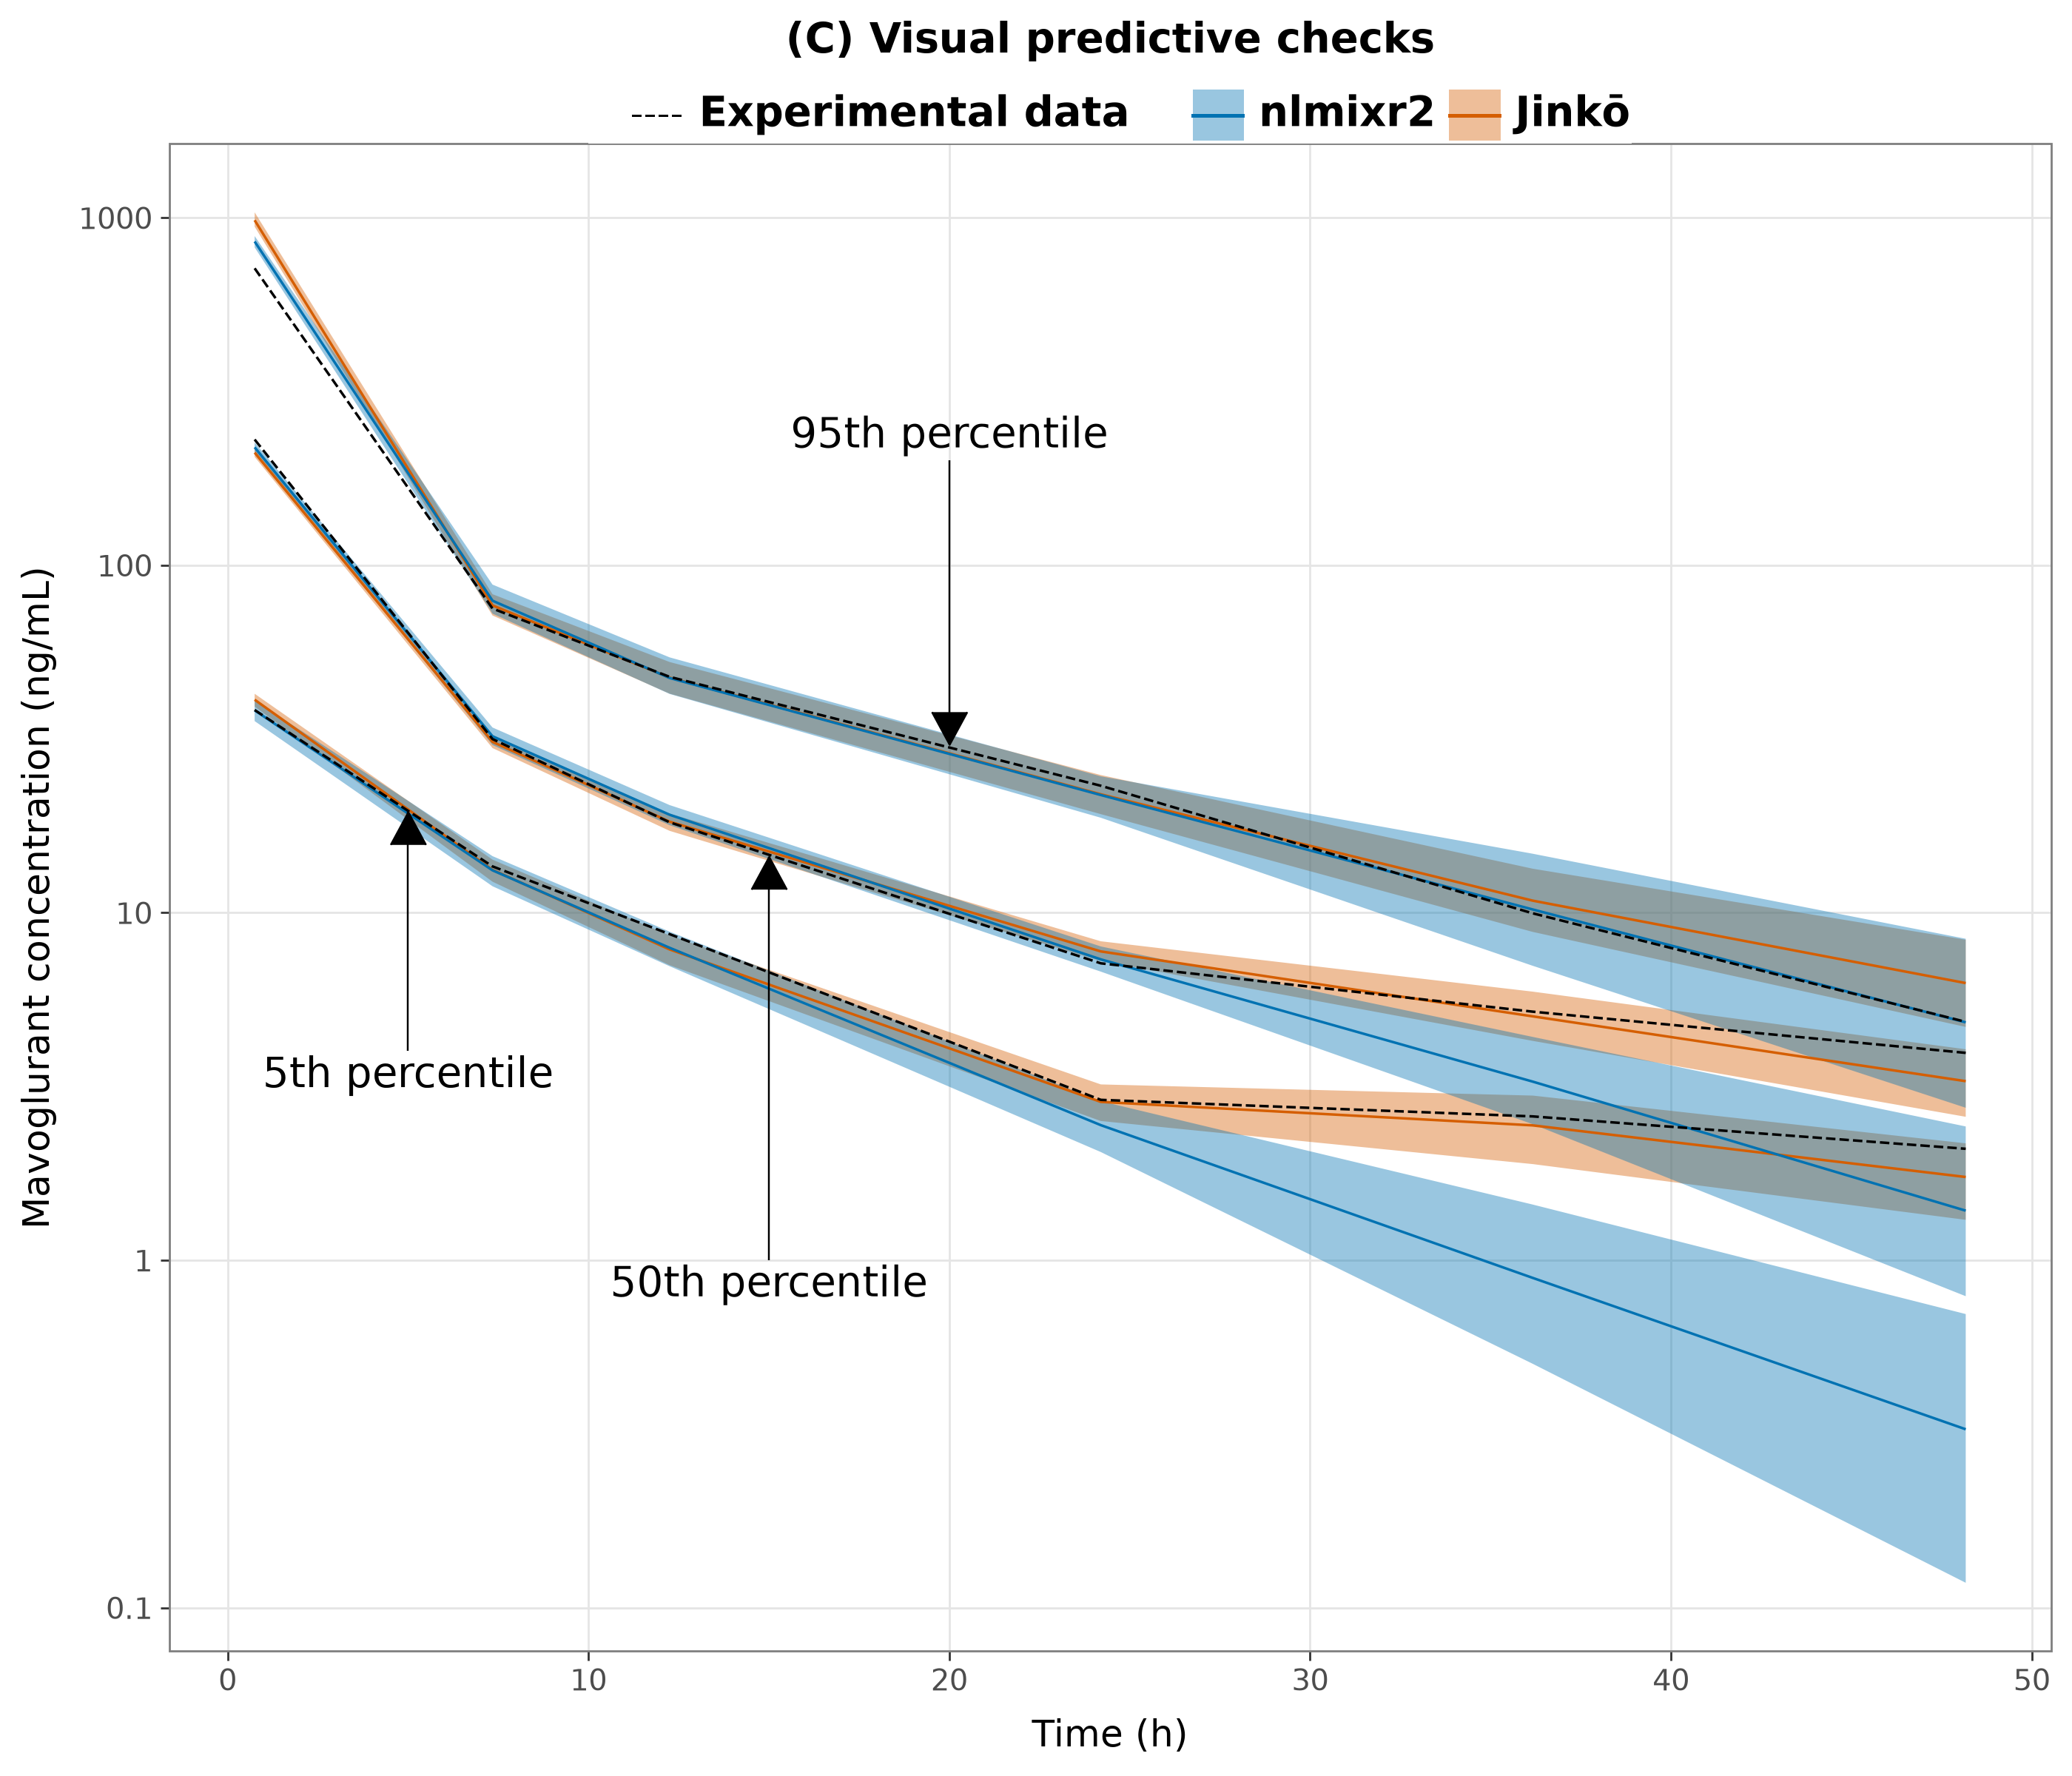

In [41]:
vpc_data = vpc_data.copy()
# Use presentation labels specific to the two VPC implementations.
vpc_source_labels = {"nlmixr2": "nlmixr2", "Jinkō": "Jinkō"}
vpc_sources = list(vpc_source_labels.values())
vpc_colors = {"nlmixr2": "#0072B2", "Jinkō": "#D55E00"}
vpc_data["Source"] = pd.Categorical(
    vpc_data["model"].astype(str).map(vpc_source_labels),
    categories=vpc_sources,
    ordered=True,
)
vpc_data["grp"] = (
    vpc_data["Source"].astype(str) + "|" + vpc_data["quantile"].astype(str)
)

pred = vpc_data.assign(value=vpc_data["pred_median"])
pred["grp"] = pred["Source"].astype(str) + "|" + pred["quantile"].astype(str)

obs = vpc_data[vpc_data["model"] == "nlmixr2"].assign(value=lambda d: d["q_obs"])
obs["grp"] = "obs|" + obs["quantile"].astype(str)
obs["Series"] = "Experimental data"

# Manually adjustable callout coordinates (x: time in h, y: concentration in ng/mL).
p05_label_x, p05_label_y = 5, 4
p05_arrow_x, p05_arrow_y = 5, 19.5

p50_label_x, p50_label_y = 15, 1
p50_arrow_x, p50_arrow_y = 15, 14.5

p95_label_x, p95_label_y = 20, 200
p95_arrow_x, p95_arrow_y = 20, 30.5
(
    ggplot()
    + geom_ribbon(
        vpc_data,
        aes(
            x="bin_center",
            ymin="pred_lower",
            ymax="pred_upper",
            fill="Source",
            group="grp",
        ),
        alpha=0.4,
    )
    + geom_line(
        pred, aes(x="bin_center", y="value", color="Source", group="grp"), size=0.7
    )
    + geom_line(
        obs,
        aes(x="bin_center", y="value", group="grp", linetype="Series"),
        color="black",
        size=0.7,
    )
    + annotate(
        "segment",
        x=p05_label_x,
        y=p05_label_y,
        xend=p05_arrow_x,
        yend=p05_arrow_y,
        color="black",
        size=0.5,
        arrow=arrow(type="closed", length=0.12),
    )
    + annotate(
        "text",
        x=p05_label_x,
        y=p05_label_y,
        label="5th percentile",
        ha="center",
        va="top",
        size=20,
    )
    + annotate(
        "segment",
        x=p50_label_x,
        y=p50_label_y,
        xend=p50_arrow_x,
        yend=p50_arrow_y,
        color="black",
        size=0.5,
        arrow=arrow(type="closed", length=0.12),
    )
    + annotate(
        "text",
        x=p50_label_x,
        y=p50_label_y,
        label="50th percentile",
        ha="center",
        va="top",
        size=20,
    )
    + annotate(
        "segment",
        x=p95_label_x,
        y=p95_label_y,
        xend=p95_arrow_x,
        yend=p95_arrow_y,
        color="black",
        size=0.5,
        arrow=arrow(type="closed", length=0.12),
    )
    + annotate(
        "text",
        x=p95_label_x,
        y=p95_label_y,
        label="95th percentile",
        ha="center",
        va="bottom",
        size=20,
    )
    + scale_linetype_manual(values={"Experimental data": "dashed"}, name=None)
    + scale_color_manual(values=vpc_colors, name=None, limits=vpc_sources)
    + scale_fill_manual(values=vpc_colors, name=None, limits=vpc_sources)
    + guides(
        color=guide_legend(title=""),
        fill=guide_legend(title=""),
        linetype=guide_legend(title=""),
    )
    + scale_y_log10()
    + labs(
        x="Time (h)",
        y="Mavoglurant concentration (ng/mL)",
        title="(C) Visual predictive checks",
    )
    + poster_theme
    + theme(
        legend_position="top",
        legend_box="horizontal",
        legend_direction="horizontal",
        legend_text=element_text(size=20, weight="bold"),
        plot_caption=element_text(size=12, ha="left"),
        figure_size=(14, 12),
    )
)